# Lab exercise

### 🔹 Task 1: Generate a Simple Word Cloud
Before diving into **advanced word clouds**, ensure you can generate a **basic word cloud** from a text corpus.

✅ Steps:

-	Load a text dataset (e.g., a Wikipedia article or news text).
-	Remove stopwords, punctuation, and unnecessary symbols.
-	Convert the text into a word cloud image.



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jimmy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jimmy\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Successfully loaded 7837 characters from article.txt!


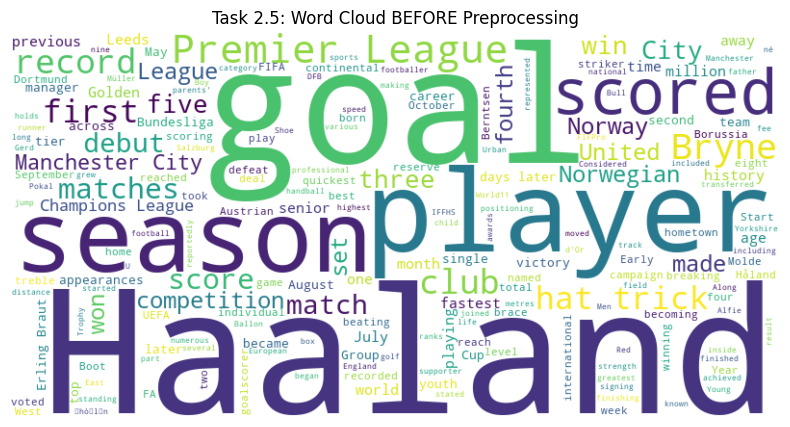

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from PIL import Image
import re

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

# Specify the name or path of your text file
file_path = 'article.txt'

# Open the file and read its contents into the 'sample_text' variable
with open(file_path, 'r', encoding='utf-8') as file:
    sample_text = file.read()

# Optional: Print the length of the text to confirm it loaded correctly
print(f"Successfully loaded {len(sample_text)} characters from {file_path}!")

# ==========================================
# Task 1
# ==========================================
# Generating a word cloud before text cleaning (includes stopwords and symbols)
wordcloud_uncleaned = WordCloud(width=800, height=400, background_color='white').generate(sample_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_uncleaned, interpolation='bilinear')
plt.axis("off")
plt.title("Task 2.5: Word Cloud BEFORE Preprocessing")
plt.show()



### 🔹 Task 2: Advanced Word Cloud Visualisation

Now, extend your basic word cloud by adding **complex features**:

✅ Steps:

1.Shape-Based Word Clouds
  
- Use a custom mask to generate a word cloud in a specific shape (e.g., a map of Vietnam, a book, or a speech bubble).
  
2.Frequency vs. TF-IDF Word Clouds

- Compare a regular frequency-based word cloud vs. a TF-IDF weighted word cloud.
-	Explain how TF-IDF gives more importance to unique words instead of commonly used ones.

3.Multi-Coloured & Themed Word Clouds

-	Use colour gradients to differentiate positive vs. negative words.
-	Create different word clouds for different topics in the same dataset.

4.Bigrams & Phrase-Based Word Clouds

-	Extract bigrams (two-word phrases) to include words like "Vietnam War" instead of separate words "Vietnam" and "War".

5.Compare Word Clouds Before & After Preprocessing

-	Generate one word cloud before text cleaning (including stopwords, symbols).
-	Generate another word cloud after applying lemmatisation & stopword removal.
-	Compare the differences and discuss why preprocessing improves visualisation.

### Task 2.1: Shape-based word clouds

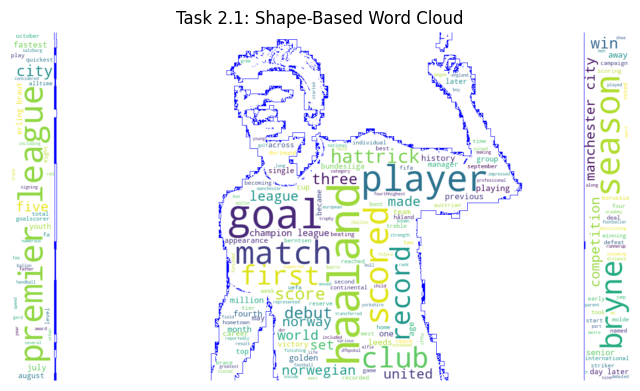

In [7]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

def clean_text(text):
    # Remove punctuation and numbers
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    
    # Instantiate the lemmatizer
    lemmatizer = WordNetLemmatizer()
    
    # Load the set of english stop words
    stop_words = set(stopwords.words('english'))
    
    # Convert to lowercase, remove stopwords, and lemmatize
    words = [lemmatizer.lemmatize(word.lower()) for word in text.split() if word.lower() not in stop_words]
    
    return " ".join(words)


cleaned_text = clean_text(sample_text)
# 1. Load the image mask
mask_image = np.array(Image.open("haaland.jpg"))

# 2. Generate the word cloud using the actual string variable (cleaned_text)
wordcloud_shape = WordCloud(background_color="white", 
                            mask=mask_image, 
                            contour_width=1, 
                            contour_color='blue').generate(cleaned_text)

# 3. Plot the result
plt.figure(figsize=(8, 8))
plt.imshow(wordcloud_shape, interpolation='bilinear')
plt.axis("off")
plt.title("Task 2.1: Shape-Based Word Cloud")
plt.show()

### Task 2.2: Frequency vs TF-IFD wordclouds

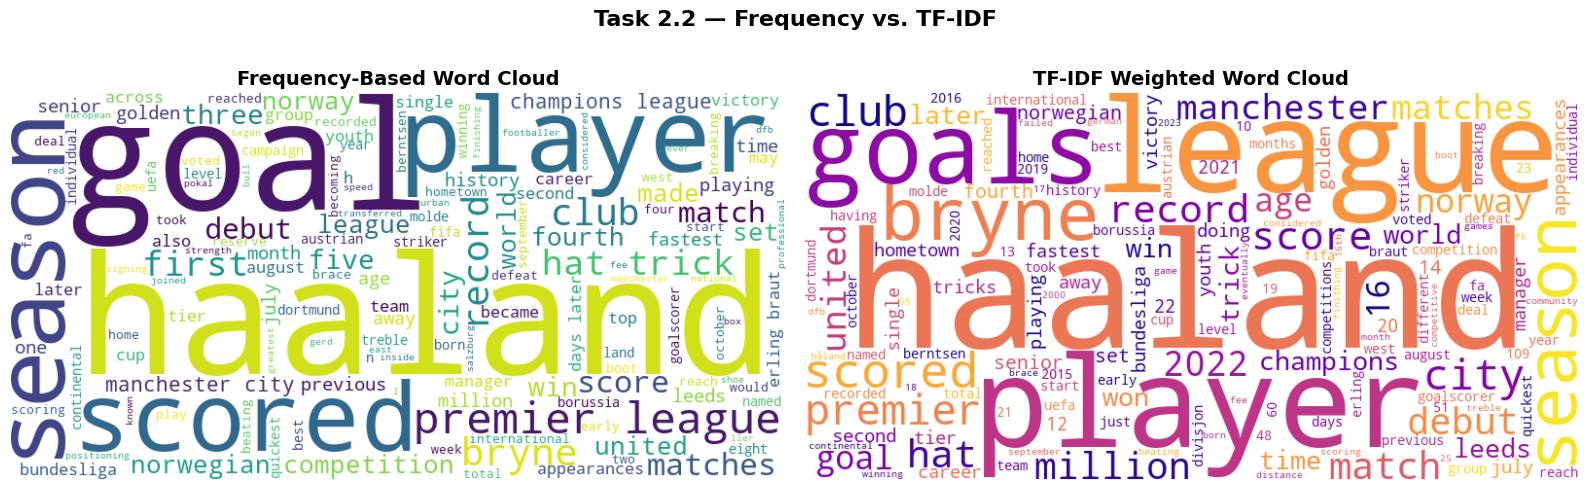


Discussion:
- The frequency cloud is dominated by very common words (even after stopword removal).
- The TF-IDF cloud highlights words that are distinctive to specific sentences/topics,
  making the key themes of the article far more visible.



In [8]:
# ─── Task 2.2: Frequency-based vs. TF-IDF Word Cloud ─────────────────────────
#
# A regular word cloud weights words by raw count.
# TF-IDF (Term Frequency–Inverse Document Frequency) down-weights words that
# appear in many documents, so unique/topic-specific words stand out more.

# --- Helper: basic text cleaning ---
def clean_text(text):
    """Lowercase, remove punctuation, strip extra whitespace."""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

SW = set(stopwords.words("english"))  # NLTK English stopword list

cleaned = clean_text(sample_text)

# ── 2.2a  Frequency-based word cloud ────────────────────────────────────────
freq_wc = WordCloud(
    width=800, height=400,
    background_color="white",
    stopwords=SW,
    max_words=150,
    colormap="viridis",
).generate(cleaned)

# ── 2.2b  TF-IDF word cloud ─────────────────────────────────────────────────
# Split article into sentences to treat each as a "document"
sentences = [s.strip() for s in sample_text.split(".") if len(s.strip()) > 10]

tfidf = TfidfVectorizer(stop_words="english", max_features=200)
tfidf_matrix = tfidf.fit_transform(sentences)

# Sum TF-IDF scores across all sentences → global importance per word
tfidf_scores = dict(
    zip(tfidf.get_feature_names_out(),
        np.asarray(tfidf_matrix.sum(axis=0)).flatten())
)

tfidf_wc = WordCloud(
    width=800, height=400,
    background_color="white",
    max_words=150,
    colormap="plasma",
).generate_from_frequencies(tfidf_scores)

# ── Plot side-by-side ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(freq_wc, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Frequency-Based Word Cloud", fontsize=14, fontweight="bold")

axes[1].imshow(tfidf_wc, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("TF-IDF Weighted Word Cloud", fontsize=14, fontweight="bold")

plt.suptitle("Task 2.2 — Frequency vs. TF-IDF", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── Discussion ───────────────────────────────────────────────────────────────
print("""
Discussion:
- The frequency cloud is dominated by very common words (even after stopword removal).
- The TF-IDF cloud highlights words that are distinctive to specific sentences/topics,
  making the key themes of the article far more visible.
""")


### Task 2.3: Multi-Coloured & Themed Word Clouds

-	Use colour gradients to differentiate positive vs. negative words.
-	Create different word clouds for different topics in the same dataset.


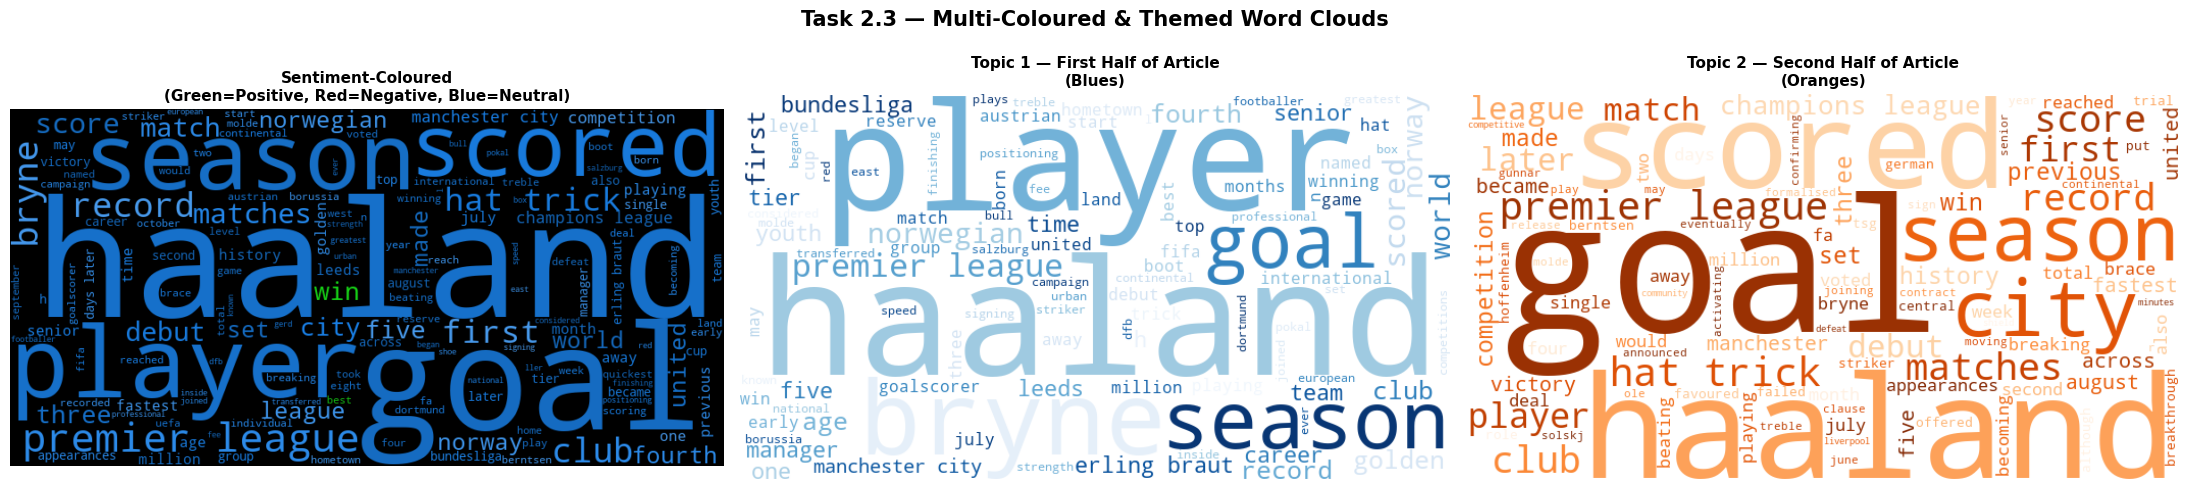

Colour gradients help the reader immediately associate word tone/topic without reading every word.


In [9]:
# ─── Task 2.3: Multi-Coloured & Themed Word Clouds ───────────────────────────
#
# Demonstrate two ideas:
#   (a) Colour gradient to separate "positive" vs "negative" sentiment words.
#   (b) Two separate word clouds built from different topic sub-sets of the text.

# ── (a) Positive / Negative colour gradient ──────────────────────────────────
# Simple lexicon-based split; replace with actual sentiment lexicon if available
POSITIVE_WORDS = {
    "great", "excellent", "amazing", "best", "wonderful", "fantastic",
    "outstanding", "superb", "innovative", "success", "win", "positive",
    "improve", "benefit", "efficient", "effective", "creative"
}
NEGATIVE_WORDS = {
    "bad", "poor", "terrible", "worst", "horrible", "failure", "fail",
    "problem", "issue", "concern", "difficult", "risk", "threat", "loss",
    "decline", "negative", "weak", "limited"
}

def sentiment_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    """Colour positive words green, negative words red, neutral words blue."""
    word_l = word.lower()
    if word_l in POSITIVE_WORDS:
        hue = 120          # green
    elif word_l in NEGATIVE_WORDS:
        hue = 0            # red
    else:
        hue = 210          # blue
    saturation = 80
    lightness  = 40 + random_state.randint(0, 20) if random_state else 50
    return f"hsl({hue}, {saturation}%, {lightness}%)"

sentiment_wc = WordCloud(
    width=800, height=400,
    background_color="black",
    stopwords=SW,
    max_words=150,
    color_func=sentiment_color_func,
).generate(cleaned)

# ── (b) Split text into first-half / second-half as two "topics" ─────────────
mid = len(cleaned) // 2
topic1_text = cleaned[:mid]
topic2_text = cleaned[mid:]

topic1_wc = WordCloud(
    width=700, height=380,
    background_color="white",
    stopwords=SW,
    max_words=100,
    colormap="Blues",
).generate(topic1_text)

topic2_wc = WordCloud(
    width=700, height=380,
    background_color="white",
    stopwords=SW,
    max_words=100,
    colormap="Oranges",
).generate(topic2_text)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

axes[0].imshow(sentiment_wc, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Sentiment-Coloured\n(Green=Positive, Red=Negative, Blue=Neutral)",
                  fontsize=11, fontweight="bold")

axes[1].imshow(topic1_wc, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Topic 1 — First Half of Article\n(Blues)", fontsize=11, fontweight="bold")

axes[2].imshow(topic2_wc, interpolation="bilinear")
axes[2].axis("off")
axes[2].set_title("Topic 2 — Second Half of Article\n(Oranges)", fontsize=11, fontweight="bold")

plt.suptitle("Task 2.3 — Multi-Coloured & Themed Word Clouds",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Colour gradients help the reader immediately associate word tone/topic without reading every word.")

### Task 2.4: Bigrams & Phrase-Based Word Clouds

-	Extract bigrams (two-word phrases) to include words like "Vietnam War" instead of separate words "Vietnam" and "War".

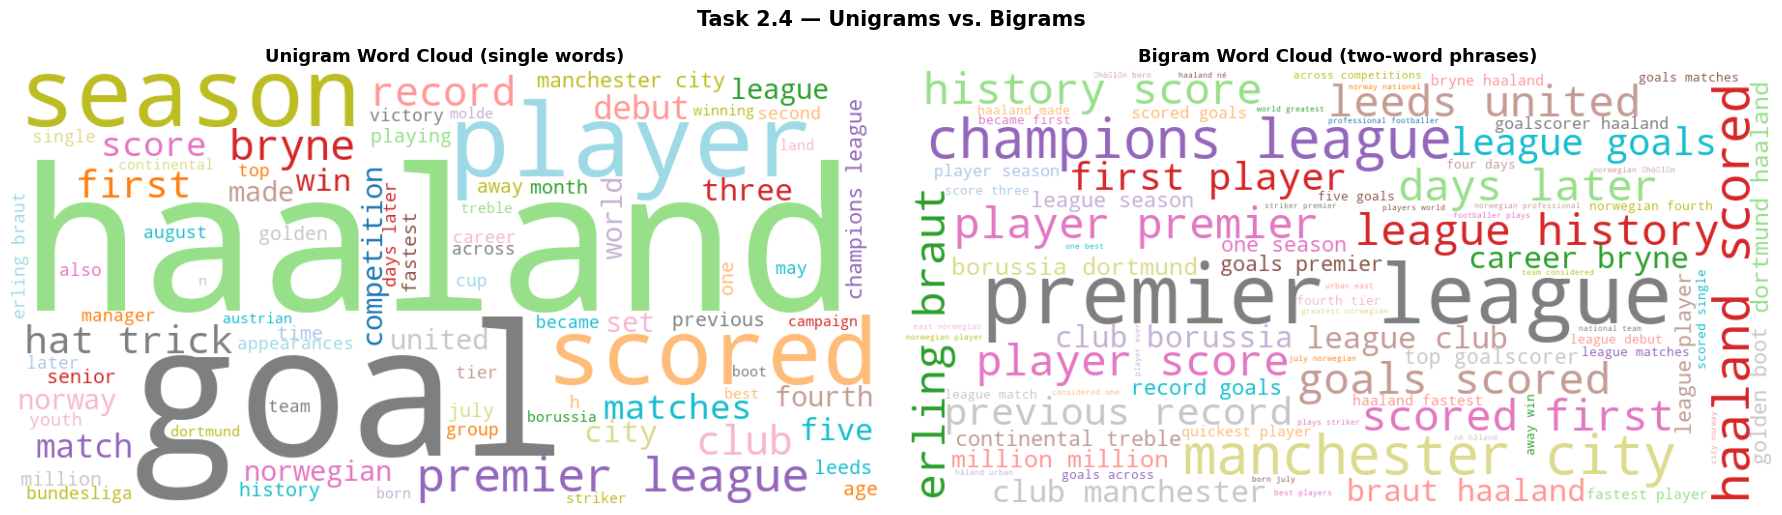

Top 15 Bigrams:
  'premier league': 15
  'manchester city': 5
  'champions league': 5
  'haaland scored': 4
  'erling braut': 3
  'goals scored': 3
  'player premier': 3
  'player score': 3
  'leeds united': 3
  'days later': 3
  'scored first': 3
  'league history': 3
  'history score': 3
  'previous record': 3
  'first player': 3


In [10]:
# ─── Task 2.4: Bigrams & Phrase-Based Word Clouds ────────────────────────────
#
# Individual words lose context ("New" and "York" separately vs "New York").
# Bigrams (two-word phrases) preserve that context.

from nltk.tokenize import word_tokenize
from nltk.util import ngrams
nltk.download('punkt',        quiet=True)
nltk.download('punkt_tab',    quiet=True)

def get_bigram_freq(text, stopwords_set):
    """Tokenise, remove stopwords, extract bigrams and return frequency dict."""
    tokens = word_tokenize(text.lower())
    # Keep only alphabetic tokens that are not stopwords
    tokens = [t for t in tokens if t.isalpha() and t not in stopwords_set]
    bigram_list = list(ngrams(tokens, 2))                 # all consecutive pairs
    freq = {}
    for bg in bigram_list:
        phrase = " ".join(bg)
        freq[phrase] = freq.get(phrase, 0) + 1
    return freq

bigram_freq = get_bigram_freq(sample_text, SW)

# ── Word cloud from bigram frequencies ───────────────────────────────────────
bigram_wc = WordCloud(
    width=900, height=450,
    background_color="white",
    max_words=80,
    colormap="tab20",
    prefer_horizontal=0.9,
).generate_from_frequencies(bigram_freq)

# ── Unigram cloud for comparison ─────────────────────────────────────────────
unigram_wc = WordCloud(
    width=900, height=450,
    background_color="white",
    stopwords=SW,
    max_words=80,
    colormap="tab20",
).generate(cleaned)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].imshow(unigram_wc, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Unigram Word Cloud (single words)", fontsize=13, fontweight="bold")

axes[1].imshow(bigram_wc, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Bigram Word Cloud (two-word phrases)", fontsize=13, fontweight="bold")

plt.suptitle("Task 2.4 — Unigrams vs. Bigrams", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Print top 15 bigrams
sorted_bigrams = sorted(bigram_freq.items(), key=lambda x: x[1], reverse=True)[:15]
print("Top 15 Bigrams:")
for phrase, count in sorted_bigrams:
    print(f"  '{phrase}': {count}")


### Task 2.5: Before Preprocessing

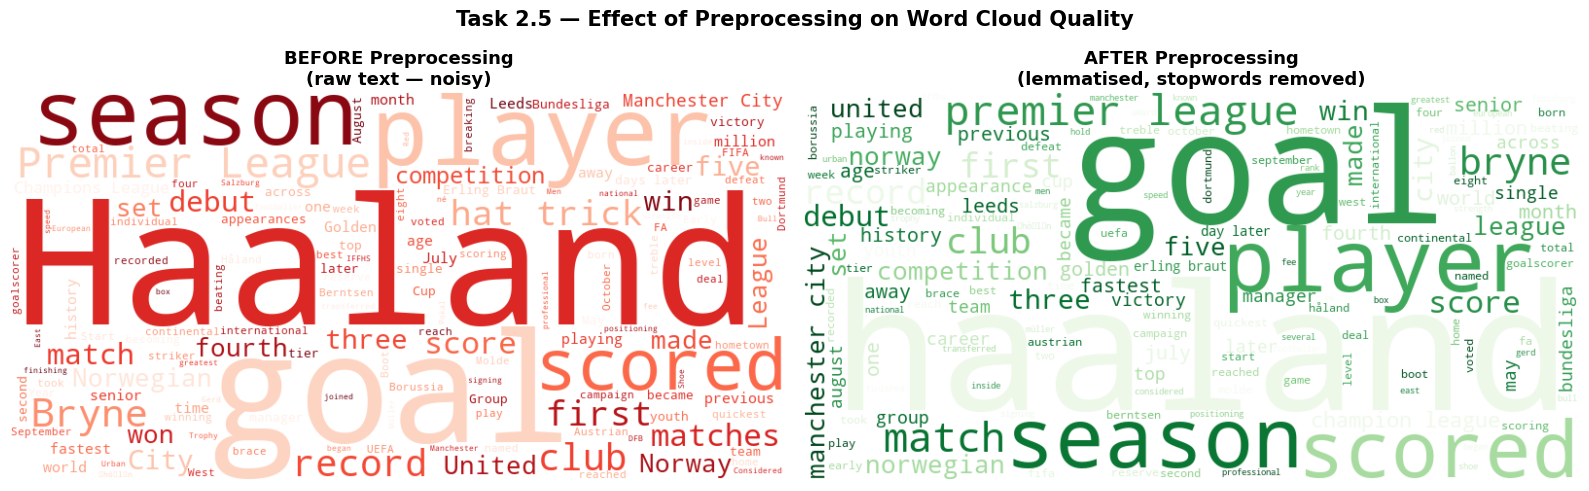


Key observations:
• BEFORE: stopwords ('the', 'is', 'and') dominate; punctuation/numbers add noise.
• AFTER : meaningful, content-bearing words and normalised word forms appear.



In [11]:
# ─── Task 2.5: Compare Word Clouds Before & After Preprocessing ───────────────
#
# Before: raw text (with stopwords, punctuation, numbers).
# After : lemmatised text with stopwords and non-alphabetic tokens removed.

lemmatizer = WordNetLemmatizer()

def preprocess(text):
    """Full NLP preprocessing pipeline: lowercase → tokenise → remove
    stopwords & non-alpha → lemmatise → rejoin."""
    tokens = word_tokenize(text.lower())
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t.isalpha() and t not in SW]
    return " ".join(tokens)

preprocessed_text = preprocess(sample_text)

# ── Before cloud — raw text ───────────────────────────────────────────────────
before_wc = WordCloud(
    width=800, height=400,
    background_color="white",
    max_words=150,
    colormap="Reds",
).generate(sample_text)

# ── After cloud — cleaned & lemmatised ───────────────────────────────────────
after_wc = WordCloud(
    width=800, height=400,
    background_color="white",
    max_words=150,
    colormap="Greens",
).generate(preprocessed_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(before_wc, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("BEFORE Preprocessing\n(raw text — noisy)", fontsize=13, fontweight="bold")

axes[1].imshow(after_wc, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("AFTER Preprocessing\n(lemmatised, stopwords removed)",
                  fontsize=13, fontweight="bold")

plt.suptitle("Task 2.5 — Effect of Preprocessing on Word Cloud Quality",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("""
Key observations:
• BEFORE: stopwords ('the', 'is', 'and') dominate; punctuation/numbers add noise.
• AFTER : meaningful, content-bearing words and normalised word forms appear.
""")


# Lab assignment

In [ ]:
# Task 1: Install Required Libraries
# !pip install wikipedia-api spacy gensim pyLDAvis matplotlib
# !python -m spacy download en_core_web_sm

  Using cached wikipedia_api-0.12.0-py3-none-any.whl (76 kB)
     --------------------------------------- 15.4/15.4 MB 24.2 MB/s eta 0:00:00
  Using cached gensim-4.4.0-cp310-cp310-win_amd64.whl (24.4 MB)
  Using cached pyLDAvis-3.4.1-py3-none-any.whl (2.6 MB)
  Using cached click-8.3.1-py3-none-any.whl (108 kB)
  Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl (28 kB)
     -------------------------------------- 153.7/153.7 kB 9.6 MB/s eta 0:00:00
     ---------------------------------------- 114.4/114.4 kB ? eta 0:00:00
  Using cached idna-3.11-py3-none-any.whl (71 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)
  Using cached h11-0.16.0-py3-none-any.whl (37 kB)
  Using cached murmurhash-1.0.15-cp310-cp310-win_amd64.whl (25 kB)
     ---------------------------------------- 50.7/50.7 kB ? eta 0:00:00
  Using cached typer-0.24.1-py3-none-any.whl (56 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl (27 kB)
  Using cached catalo


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     --------------------------------------- 12.8/12.8 MB 26.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import wikipediaapi

# Task 3: Fetch Wikipedia Articles
# Ensure you include a user agent in your API request
wiki_wiki = wikipediaapi.Wikipedia('LabAssignment1/1.0 (jimmtrn154@gmail.com)', 'en')

topics = [
    "Vietnam", 
    "Vietnamese language", 
    "Ho Chi Minh", 
    "Vietnam War"
]

documents = []

for topic in topics:
    page = wiki_wiki.page(topic)
    # Handle cases where an article does not exist
    if page.exists():
        print(f"Successfully fetched: {topic}")
        documents.append(page.text)
    else:
        print(f"Warning: Article '{topic}' does not exist.")

Successfully fetched: Vietnam
Successfully fetched: Vietnamese language
Successfully fetched: Ho Chi Minh
Successfully fetched: Vietnam War


In [ ]:
# !pip install --upgrade typing_extensions pydantic


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import spacy

# Task 4: Text Preprocessing with spaCy
nlp = spacy.load("en_core_web_sm")

def preprocess_text(text):
    # Process the text using spaCy
    doc = nlp(text)
    
    processed_tokens = []
    for token in doc:
        # Convert to lowercase, remove stopwords, tokenize, and lemmatize
        if not token.is_stop and not token.is_punct and not token.is_space:
            processed_tokens.append(token.lemma_.lower())
            
    return processed_tokens

# Apply preprocessing to all fetched documents
processed_docs = [preprocess_text(doc) for doc in documents]
print("Preprocessing complete.")

Preprocessing complete.


In [3]:
from gensim import corpora
from gensim.models import LdaModel

# Task 5: Create & Train an LDA Model

# Create a dictionary mapping words to unique IDs
dictionary = corpora.Dictionary(processed_docs)

# Convert the processed text into a bag-of-words representation
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

# Train an LDA model with 3 topics and tune parameters
num_topics = 3
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    passes=15, # Tuned parameter to improve results
    random_state=42
)

print("LDA Model training complete.")

LDA Model training complete.


In [4]:
import pyLDAvis
import pyLDAvis.gensim_models

# Task 6: Visualise & Interpret Topics
pyLDAvis.enable_notebook()

# Create the visualization
vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)

# Save the visualisation as an HTML file
html_filename = 'lda_vietnam_topics.html'
pyLDAvis.save_html(vis, html_filename)
print(f"Visualisation saved to {html_filename}. You can open it in a browser.")

# Display the visualization in the notebook
vis

Visualisation saved to lda_vietnam_topics.html. You can open it in a browser.


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.040547  0.083659       1        1  52.262809
1     -0.063308 -0.072268       2        1  47.732707
2      0.103855 -0.011391       3        1   0.004484, topic_info=          Term        Freq       Total Category  logprob  loglift
1422        hồ  135.000000  135.000000  Default  30.0000  30.0000
4699       chí   60.000000   60.000000  Default  29.0000  29.0000
2855   vietnam  555.000000  555.000000  Default  28.0000  28.0000
6830        vc   56.000000   56.000000  Default  27.0000  27.0000
1771      minh  172.000000  172.000000  Default  26.0000  26.0000
...        ...         ...         ...      ...      ...      ...
2686      time    0.000212   47.462638   Topic3  -8.7622  -2.3066
2506  southern    0.000212   56.267495   Topic3  -8.7614  -2.4759
2852      viet    0.000212   60.616810   Topic3  -8.7601  -2.5491
2931      word    0.000212   67.802212   Topic3  -8.7603  -2.6613
4699       chí    0.000212   60.951318   Topic3  -8.7614  -2.5560

[230 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
4535      2  0.694668    24,000
3176      1  0.989933         >
4582      2  0.694713    allege
3206      1  0.947253  alphabet
4586      2  0.694664     alsop
...     ...       ...       ...
2952      1  0.228824      year
2952      2  0.756880      year
2968      2  1.006569         °
2971      2  0.936117        áo
5568      2  0.694679         志

[222 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3])

## Question to answer:

1. Words define each topic:
- Topic 1: vietnamese, south, north, war, military, force, troop, civilian
- Topic 2: việt, chi, international, world, hanoi, people, minh, french
- Topic 3: communist, chinese, government, language

2. Wikipedia articles actually determine those topic directly. For example, words mentioned in topic 1 is related to the article Vietnam war, topic 2 is related to Vietnam in general and topc 3 related to the article Vietnamese language

3. The subjects such as Vietnam, Vietnamese language and Vietnam war are relatively correalated together so minor overlap is inevitable. Massive amount of identical vocabulary such as vietnamese, việt, vietnam... However, based on the 2D space diagram, there is no major overlap at all, the distance between circles indicates how similar topics are. 

4. Adjusting the relevance slider lambda in pyLDAvis can shift how the model ranks the most important words for a topic:
- Move lambda closer to 1 then the chart will prioritize words that appear the most within a topic
- Move lambda closer to 0 then the chart will prioritize unique/rare words for a certain topic. 

5. LDA provides a powerful way to discover hidden themes in unstructural text without reading every document. We can see the relationship among topics in 2D space. 